# DID: ChatGPT Impact on Employment and Wages (LM_AIOE + MS_SCORE, unified)

Consolidates `did_regression.ipynb` (LM_AIOE only) and the no-control half of `did_with_controls.ipynb` (MS_SCORE only) into one file, so both indices go through the exact same pipeline instead of two separately-maintained scripts that can silently drift apart (as happened with the 2022 vs 2023 post-period definition in the SC/GSC scripts).

No Job Zone control here — see `did_with_controls_unified.ipynb` for the with/without Job Zone comparison, for both indices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from linearmodels.panel import PanelOLS

df = pd.read_csv('bls_onet_felten_ms_panel_harmonised.csv')
df = df[~df['year'].isin([2020, 2021])].copy()

df['TOT_EMP']  = pd.to_numeric(df['TOT_EMP'], errors='coerce')
df['A_MEDIAN'] = pd.to_numeric(df['A_MEDIAN'], errors='coerce')
df['log_emp']  = np.log(df['TOT_EMP'].replace(0, np.nan))
df['log_wage'] = np.log(df['A_MEDIAN'].replace(0, np.nan))

# Post-treatment dummy: 1 if year >= 2023 (2022 is still pre, OEWS is a May survey)
df['post'] = (df['year'] >= 2023).astype(int)

print(f'Base panel rows (before per-index filtering): {len(df)}')
print(f'Years: {sorted(df["year"].unique())}')

Base panel rows (before per-index filtering): 219783
Years: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## Config: the two indices this notebook runs through the same pipeline
Each index gets its own `notna()` filter, its own standardisation, and its own `did`/event-study columns — the two branches never share rows, so results are comparable but not accidentally cross-contaminated.

In [2]:
INDICES = [
    {'col': 'LM_AIOE',  'std_col': 'aioe_std', 'label': 'LM_AIOE'},
    {'col': 'MS_SCORE', 'std_col': 'ms_std',   'label': 'MS_SCORE'},
]
OUTCOMES = ['log_emp', 'log_wage']

def prep_index_panel(base_df, idx_col, std_col):
    """Filter to rows with this index available, standardise, build did + unit index."""
    d = base_df[base_df[idx_col].notna()].copy()
    d[std_col] = (d[idx_col] - d[idx_col].mean()) / d[idx_col].std()
    d['did'] = d[std_col] * d['post']
    d['unit'] = d['OCC_CODE'] + '_' + d['NAICS'].astype(str)
    return d

panels = {ix['label']: prep_index_panel(df, ix['col'], ix['std_col']) for ix in INDICES}
for label, d in panels.items():
    print(f'{label}: {len(d)} rows, {d["OCC_CODE"].nunique()} occupations')

LM_AIOE: 178979 rows, 688 occupations
MS_SCORE: 203165 rows, 785 occupations


## Pooled DID (single post dummy) — both indices, both outcomes

In [3]:
pooled_results = {}

for ix in INDICES:
    label = ix['label']
    d = panels[label].set_index(['unit', 'year'])
    for outcome in OUTCOMES:
        sample = d[[outcome, 'did']].dropna()
        model = PanelOLS.from_formula(f'{outcome} ~ did + EntityEffects + TimeEffects', data=sample)
        res = model.fit(cov_type='clustered', cluster_entity=True)
        pooled_results[(label, outcome)] = res
        print(f'=== {label} x {outcome} ===')
        print(res.summary)
        print()

=== LM_AIOE x log_emp ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                log_emp   R-squared:                        0.0012
Estimator:                   PanelOLS   R-squared (Between):           2.171e-05
No. Observations:              168465   R-squared (Within):               0.0013
Date:                Sat, Aug 01 2026   R-squared (Overall):           6.473e-05
Time:                        17:09:37   Log-likelihood                -7.768e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      180.18
Entities:                       19684   P-value                           0.0000
Avg Obs:                       8.5585   Distribution:                F(1,148769)
Min Obs:                       1.0000                                           
Max Obs:                       12.000   F-statistic (robust):             41.890
  

## Event study (year-by-year coefficients) — both indices, both outcomes
2022 is the omitted reference year (k=-1). Years are read from the data, not hardcoded, so this automatically covers 2012-2014 without anyone needing to remember to update a list.

In [4]:
def run_event_study(base_df, idx_col, std_col, outcome):
    d = base_df[base_df[idx_col].notna()].copy()
    d[std_col] = (d[idx_col] - d[idx_col].mean()) / d[idx_col].std()
    years = [y for y in sorted(d['year'].unique()) if y != 2022]
    for y in years:
        d[f'idx_X_{y}'] = d[std_col] * (d['year'] == y).astype(int)
    d['unit'] = d['OCC_CODE'] + '_' + d['NAICS'].astype(str)
    d = d.set_index(['unit', 'year'])
    interaction_terms = ' + '.join([f'idx_X_{y}' for y in years])
    formula = f'{outcome} ~ {interaction_terms} + EntityEffects + TimeEffects'
    cols = [outcome] + [f'idx_X_{y}' for y in years]
    sample = d[cols].dropna()
    res = PanelOLS.from_formula(formula, data=sample).fit(cov_type='clustered', cluster_entity=True)
    return res, years

event_study_results = {}
for ix in INDICES:
    for outcome in OUTCOMES:
        res, years = run_event_study(df, ix['col'], ix['std_col'], outcome)
        event_study_results[(ix['label'], outcome)] = (res, years)
        print(f'--- Event study: {ix["label"]} x {outcome} done ({len(years)} non-reference years) ---')

--- Event study: LM_AIOE x log_emp done (11 non-reference years) ---
--- Event study: LM_AIOE x log_wage done (11 non-reference years) ---
--- Event study: MS_SCORE x log_emp done (11 non-reference years) ---
--- Event study: MS_SCORE x log_wage done (11 non-reference years) ---


## Event study plots — 2x2 grid (index x outcome)

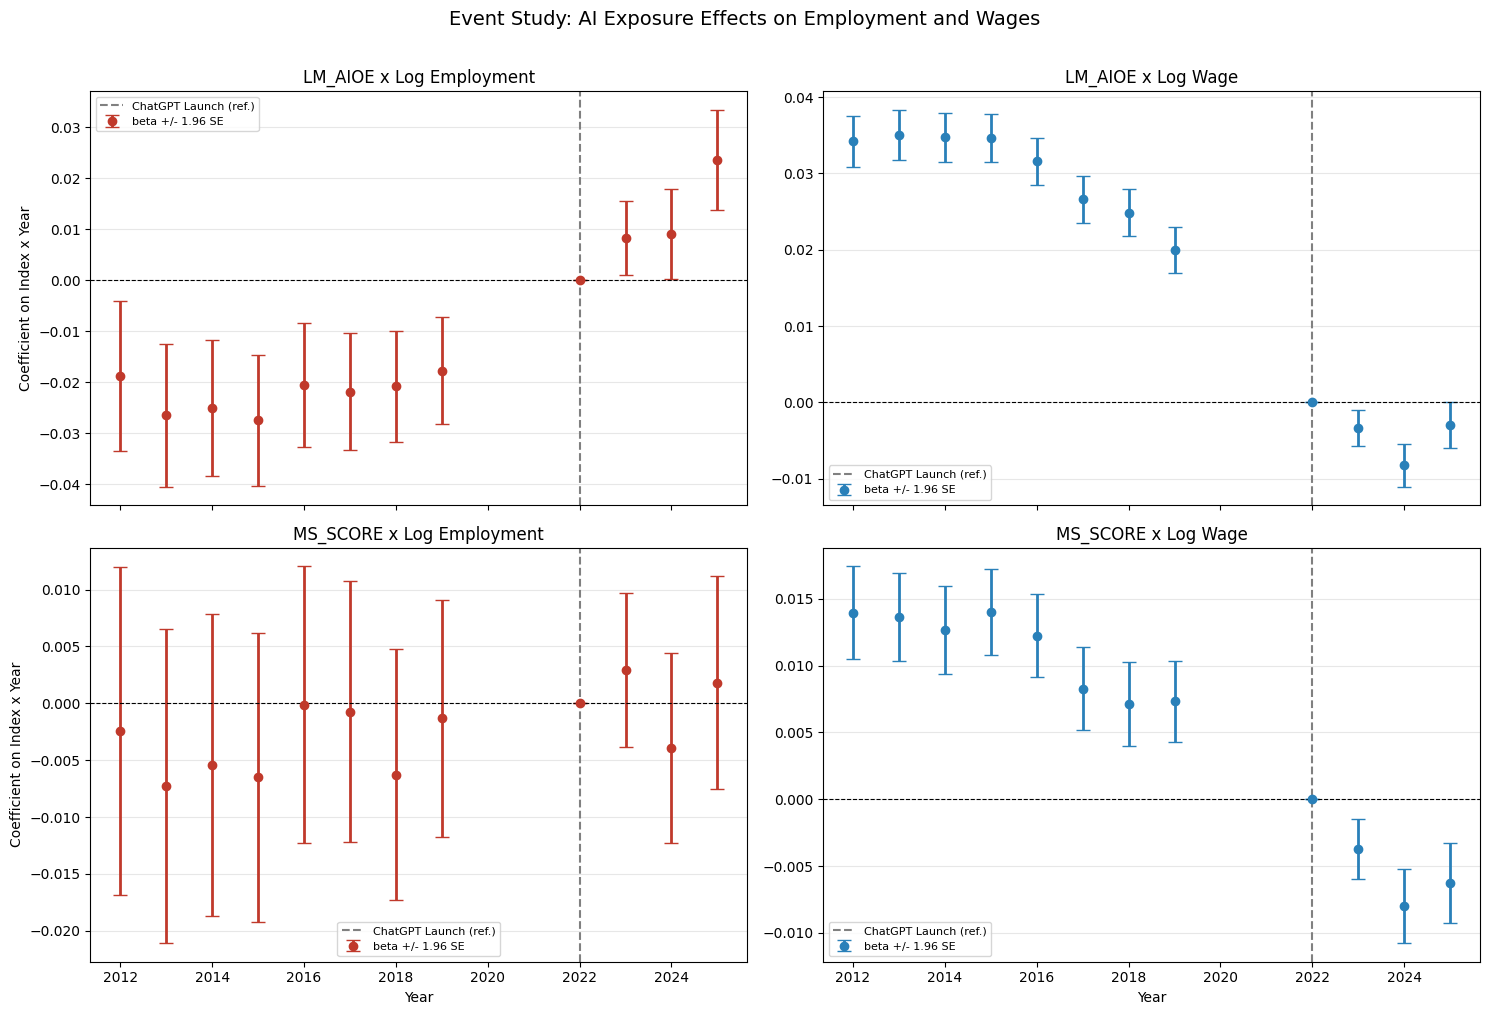

Saved event_study_did_unified.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
colors = {'log_emp': '#C0392B', 'log_wage': '#2980B9'}
outcome_titles = {'log_emp': 'Log Employment', 'log_wage': 'Log Wage'}

for row, ix in enumerate(INDICES):
    for col, outcome in enumerate(OUTCOMES):
        res, years = event_study_results[(ix['label'], outcome)]
        coef_names = [f'idx_X_{y}' for y in years]
        coefs = res.params[coef_names].values
        ses = res.std_errors[coef_names].values

        all_years = years + [2022]
        all_coefs = list(coefs) + [0]
        all_ses = list(ses) + [0]
        sorted_data = sorted(zip(all_years, all_coefs, all_ses))
        plot_years, plot_coefs, plot_ses = zip(*sorted_data)

        ax = axes[row, col]
        ax.errorbar(plot_years, plot_coefs, yerr=1.96*np.array(plot_ses),
                    fmt='o', color=colors[outcome], linewidth=2,
                    capsize=5, markersize=6, label='beta +/- 1.96 SE')
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.axvline(2022, color='gray', linewidth=1.5, linestyle='--', label='ChatGPT Launch (ref.)')
        ax.set_title(f"{ix['label']} x {outcome_titles[outcome]}", fontsize=12)
        ax.grid(axis='y', alpha=0.3)
        if row == 1:
            ax.set_xlabel('Year')
        if col == 0:
            ax.set_ylabel('Coefficient on Index x Year')
        ax.legend(fontsize=8)

plt.suptitle('Event Study: AI Exposure Effects on Employment and Wages', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('event_study_did_unified.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved event_study_did_unified.png')

## Summary table: pooled DID coefficient by index x outcome

In [6]:
rows = []
for (label, outcome), res in pooled_results.items():
    rows.append({
        'index': label,
        'outcome': outcome,
        'coef': res.params['did'],
        'se': res.std_errors['did'],
        'pvalue': res.pvalues['did'],
        'n_obs': res.nobs,
    })

summary = pd.DataFrame(rows)
summary.to_csv('did_pooled_summary.csv', index=False)
print(summary.to_string(index=False))

   index  outcome      coef       se       pvalue  n_obs
 LM_AIOE  log_emp  0.032734 0.005058 9.683676e-11 168465
 LM_AIOE log_wage -0.030763 0.001099 0.000000e+00 175528
MS_SCORE  log_emp  0.003454 0.004909 4.815986e-01 191707
MS_SCORE log_wage -0.015278 0.001136 0.000000e+00 198998
